In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from braid_analysis import braid_analysis_plots
from align_course_direction_analysis import unifying_algo_analysis as uaa
from align_course_direction_analysis import unifying_algo_plots as uap

import figurefirst as fifi

import copy

In [2]:
def remove_jumps(A):
    a = copy.copy(A)
    ix = np.where(np.abs(np.diff(a))>5)[0]
    a[ix+1] = np.nan
    return a

def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

In [3]:
laminar_color = '#991128ff'
still_color = '#084a72ff'

In [4]:
unifying_algo_fit_still = pd.read_parquet('shark_a_unifying_analysis.parquet')
still_trajec = pd.read_parquet('shark_a_trajec.parquet')

In [5]:
unifying_algo_fit_laminar = pd.read_parquet('shark_d_unifying_analysis.parquet')
laminar_trajec = pd.read_parquet('shark_d_trajec.parquet')

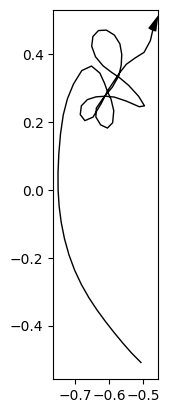

In [6]:
braid_analysis_plots.plot_arrowhead_trajectory(still_trajec.x.values,
                                               still_trajec.y.values)

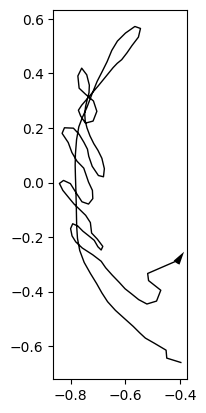

In [7]:
braid_analysis_plots.plot_arrowhead_trajectory(laminar_trajec.x.values,
                                               laminar_trajec.y.values)

In [8]:
unifying_algo_fit_laminar.rotation *= -1

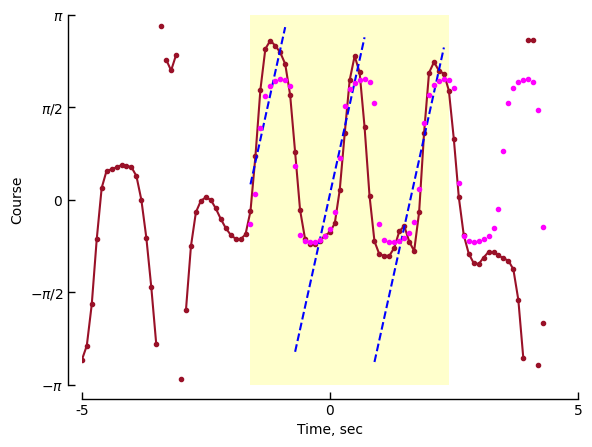

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

unifying_algo_fit = unifying_algo_fit_laminar
course = laminar_trajec.course_smoothish.values

sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

#course = course - (best_unifying_algo_fit.rotation + np.pi/2)
course = wrap_angle(course)

ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit,
                                                                                                     normalize_slope_sign=True
                                                                                                      )

#affine_fit_angle = affine_fit_angle - (best_unifying_algo_fit.rotation + np.pi/2)

abs_min_ix = best_unifying_algo_fit.min_ix
trajec = still_trajec

# shading for before search
# ax.fill_betweenx([np.pi, -np.pi], 
#                  0, 
#                  abs_min_ix, 
#                  color='gray', 
#                  alpha=0.2, 
#                  edgecolor='none', 
#                  zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix) - best_unifying_algo_fit.shift_ix
max_ix = int(best_unifying_algo_fit.max_ix) - best_unifying_algo_fit.shift_ix
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all-best_unifying_algo_fit.shift_ix, remove_jumps(course), color=laminar_color) #, '.', color='black')
ax.plot(ix_all-best_unifying_algo_fit.shift_ix, course, '.', color=laminar_color)

ax.plot(ix_all[best_unifying_algo_fit.min_ix:best_unifying_algo_fit.max_ix]-best_unifying_algo_fit.shift_ix, 
        remove_jumps(linear_fit_angle)[best_unifying_algo_fit.min_ix:best_unifying_algo_fit.max_ix], '--', color='blue')

#ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:]-best_unifying_algo_fit.shift_ix, affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(-50, 50)
ax.set_ylim(-np.pi, np.pi)

xticks = np.array([-50, 0, 50])
dt = np.median(np.diff(trajec.timestamps_sec.values))
xticklabels = (dt*xticks).astype(int)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

################################################



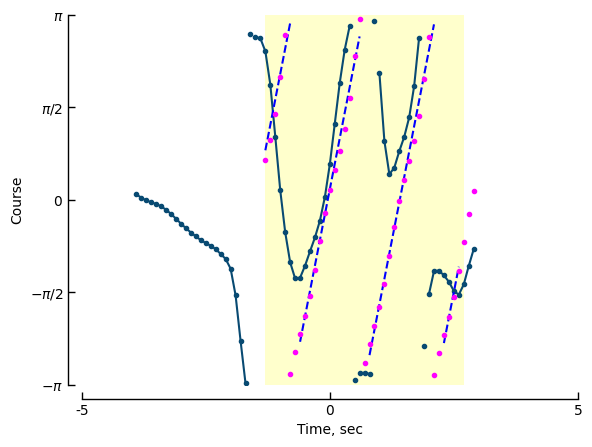

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

unifying_algo_fit = unifying_algo_fit_still
course = still_trajec.course_smoothish.values

sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

course = course - (best_unifying_algo_fit.rotation + np.pi/2)
course = wrap_angle(course)

ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit,
                                                                                                     normalize_slope_sign=True)

abs_min_ix = best_unifying_algo_fit.min_ix
trajec = still_trajec

# shading for before search
# ax.fill_betweenx([np.pi, -np.pi], 
#                  0, 
#                  abs_min_ix, 
#                  color='gray', 
#                  alpha=0.2, 
#                  edgecolor='none', 
#                  zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix) - best_unifying_algo_fit.shift_ix
max_ix = int(best_unifying_algo_fit.max_ix) - best_unifying_algo_fit.shift_ix
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all-best_unifying_algo_fit.shift_ix, remove_jumps(course), still_color) #, '.', color='black')
ax.plot(ix_all-best_unifying_algo_fit.shift_ix, course, '.', color=still_color)

ax.plot(ix_all[best_unifying_algo_fit.min_ix:best_unifying_algo_fit.max_ix]-best_unifying_algo_fit.shift_ix, 
        remove_jumps(linear_fit_angle)[best_unifying_algo_fit.min_ix:best_unifying_algo_fit.max_ix], '--', color='blue')

#ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:]-best_unifying_algo_fit.shift_ix, affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(-50, 50)
ax.set_ylim(-np.pi, np.pi)

xticks = np.array([-50, 0, 50])
dt = np.median(np.diff(trajec.timestamps_sec.values))
xticklabels = (dt*xticks).astype(int)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])